<a href="https://colab.research.google.com/github/Benswe/Easy21/blob/main/Chapter2RLbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 2.5 (programming) Design and conduct an experiment to demonstrate the
difficulties that sample-average methods have for nonstationary problems. Use a modified
version of the 10-armed testbed in which all the q*(a) start out equal and then take
independent random walks (say by adding a normally distributed increment with mean 0
and standard deviation 0.01 to all the q*(a) on each step). Prepare plots like Figure 2.2
for an an action-value method using sample averages, incrementally computed, and another
action-value method using a constant step-size parameter, $\epsilon=0.1$. Use $\alpha =0.1$ and
longer runs, say of 10,000 steps

In [1]:
import numpy as np
import matplotlib.pyplot as plt

constant_alpha = 0.1
eps = 0.1

def k_armed_bandit(k, alpha="constant", step_size=10000):
  q_star = np.zeros(k) # actual action values
  Q = np.zeros(k) # estimated action values
  N = np.zeros(k) # number of times any action is taken


  rewards = np.zeros(step_size)
  optimal_actions = np.zeros(step_size)


  for step in range(step_size):
    if np.random.rand() < eps: # eps case(choose randomly)
      action = np.random.randint(k)
    else:
      action = np.argmax(Q)

    #track optimal action per time step
    optimal_action = np.argmax(q_star)
    if action == optimal_action:
      optimal_actions[step] = 1

    N[action] += 1
    if alpha == "constant":
      step_alpha = constant_alpha
    else:
      step_alpha = 1/N[action]

    reward = np.random.normal(q_star[action], 1) # sample action from same distribution
    rewards[step] = reward

    Q[action] += step_alpha*(reward - Q[action]) # bandit update
    q_star += np.random.normal(0, 0.01, k) # mean of 1, with std deviation of 0.01

  return rewards, optimal_actions



In [2]:
runs = 2000
steps = 10000
k=10

avg_rewards_constant = np.zeros(steps)
avg_optimal_constant = np.zeros(steps)

avg_rewards_sample = np.zeros(steps)
avg_optimal_sample = np.zeros(steps)


for run in range(runs):
  rewards, optimal = k_armed_bandit(k, alpha="constant", step_size=steps)
  avg_rewards_constant += rewards
  avg_optimal_constant += optimal

  rewards, optimal = k_armed_bandit(k, alpha="sample", step_size=steps)

  avg_rewards_sample += rewards
  avg_optimal_sample += optimal


avg_rewards_constant /= runs
avg_optimal_constant /= runs

avg_rewards_sample /= runs
avg_optimal_sample /= runs

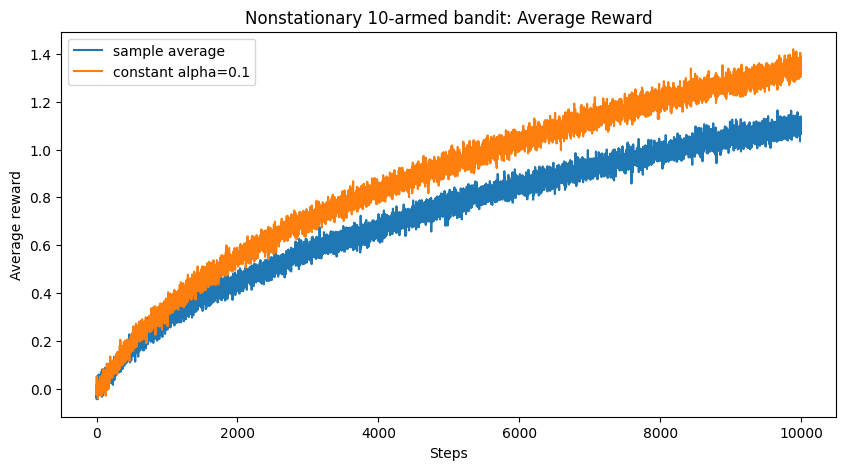

In [3]:
plt.figure(figsize=(10,5))
plt.plot(avg_rewards_sample, label="sample average")
plt.plot(avg_rewards_constant, label="constant alpha=0.1")
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("Nonstationary 10-armed bandit: Average Reward")
plt.legend()
plt.show()

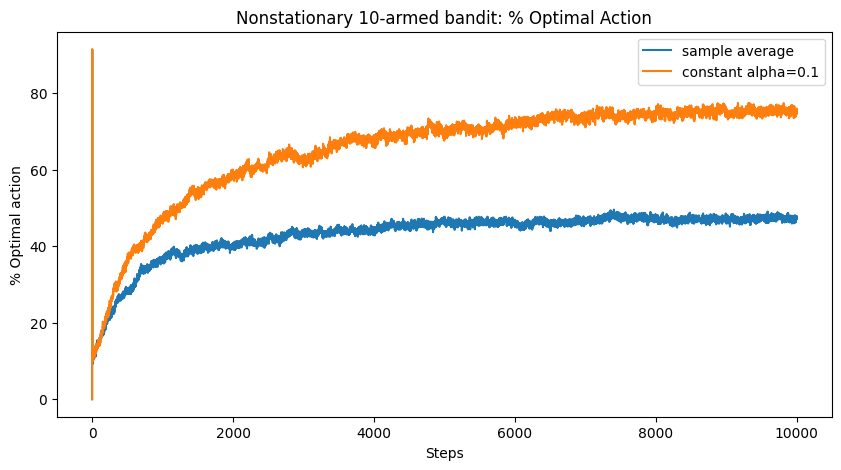

In [5]:
plt.figure(figsize=(10,5))
plt.plot(avg_optimal_sample*100, label="sample average")
plt.plot(avg_optimal_constant*100, label="constant alpha=0.1")
plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.legend()
plt.title("Nonstationary 10-armed bandit: % Optimal Action")
plt.show()
# spike at 0 is because of tiebreaking with argmax